<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/04_sustax_extreme_analysis_heatmaps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
import glob
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_PATH = "/content/drive/MyDrive/Doctorado-DCAG"
os.chdir(PROJECT_PATH)
sys.path.append(PROJECT_PATH)

print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Doctorado-DCAG


# **Imports**

In [2]:
from scripts.sustax.extremes import (
    compute_monthly_max_weekly,
    plot_percentile_heatmap,
    plot_percentile_heatmap_ssp,
    plot_daily_vs_weekly,
    get_scenario_file,
    get_available_scenarios_for_point,
    pick_precip_col,
)

# **Configuración**

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")

BYSCEN_TOTAL_FOLDER = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED", "BY_SCENARIO_TOTAL")
PHASE_B_FOLDER = os.path.join(SUSTAX_DIR, "PHASE_B_SCENARIOS")
OUT_FIG_FOLDER = os.path.join(PHASE_B_FOLDER, "FIGURES_PHASE_B")
OUT_FIG_FOLDER_SSP = os.path.join(PHASE_B_FOLDER, "FIGURES_PHASE_B_SSP_ONLY")

os.makedirs(OUT_FIG_FOLDER, exist_ok=True)
os.makedirs(OUT_FIG_FOLDER_SSP, exist_ok=True)

TARGET_DATE = "2015-10-23"
TARGET_DT = pd.Timestamp(TARGET_DATE)

PREFERRED_SCENARIOS = ["ERA5", "SSP245", "SSP370", "SSP585"]

POINTS_TO_USE = [
    "Sustax_ Manzanillo_LosReyesTotal",
    "Sustax_ManzanilloTotal",
    "Sustax_MinatitlanTotal",
    "Sustax_TecomanTotal",
    "Sustax_TolimanTotal",
    "Sustax_Veladero_de_OtatesTotal",
    "Sustax_VilladeAlvarezTotal",
    "Sustax_Zapotitlan_de_VadilloTotal",
]

SSP_LIST = ["SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP585"]

SCENARIO_COLORS = {
    "ERA5":   "#1f77b4",
    "SSP245": "#2ca02c",
    "SSP370": "#d62728",
    "SSP585": "#9467bd",
    "SSP119": "#17becf",
    "SSP126": "#8c564b",
    "SSP343": "#ff7f0e",
    "SSP434": "#bcbd22",
    "SSP460": "#7f7f7f",
}

# **Cargar tablas base**

In [4]:
df_daily = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_daily_extended.csv"))
df_monthly_daily = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_monthly_daily.csv"))
df_weekly = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_weekly.csv"))
df_combined = pd.read_csv(os.path.join(PHASE_B_FOLDER, "df_event_combined.csv"))

display(df_combined.head())
print(df_combined.columns.tolist())

,sustax_total,scenario,event_value_daily_mm,daily_percentile_full_series,daily_rank_full_series,n_days_full_series,monthly_max_daily_2015_10_mm,october_percentile_daily_max,october_rank_daily_max,n_october_years_daily_max,event_value_weekly_7d_mm,monthly_max_weekly_2015_10_mm,october_percentile_weekly_max,october_rank_weekly_max,n_october_years_weekly_max
0,Sustax_ Manzanillo_LosReyesTotal,SSP119,0.343163,62.054434,23119,37256,13.985031,73.529412,75,102,4.617921,106.399573,88.235294,90,102
1,Sustax_ Manzanillo_LosReyesTotal,SSP126,0.892510,68.405089,25485,37256,6.900040,65.686275,67,102,9.837805,29.988042,20.588235,21,102
2,Sustax_ Manzanillo_LosReyesTotal,SSP245,0.275105,61.514924,22918,37256,4.003961,27.450980,28,102,7.462686,43.745216,56.862745,58,102
3,Sustax_ Manzanillo_LosReyesTotal,SSP370,0.712683,66.730191,24861,37256,9.115235,63.725490,65,102,9.453609,370.535151,100.000000,102,102
4,Sustax_ Manzanillo_LosReyesTotal,SSP434,10.515098,91.120893,33948,37256,22.831460,47.058824,48,102,18.270972,58.979454,20.588235,21,102


['sustax_total', 'scenario', 'event_value_daily_mm', 'daily_percentile_full_series', 'daily_rank_full_series', 'n_days_full_series', 'monthly_max_daily_2015_10_mm', 'october_percentile_daily_max', 'october_rank_daily_max', 'n_october_years_daily_max', 'event_value_weekly_7d_mm', 'monthly_max_weekly_2015_10_mm', 'october_percentile_weekly_max', 'october_rank_weekly_max', 'n_october_years_weekly_max']


# **Helper local para elegir escenarios**

In [5]:
def choose_scenarios_for_plot(sustax_total):
    available = get_available_scenarios_for_point(sustax_total, BYSCEN_TOTAL_FOLDER)

    chosen = []
    for sc in PREFERRED_SCENARIOS:
        if sc in available:
            chosen.append(sc)

    if len(chosen) < 4:
        for sc in available:
            if sc not in chosen:
                chosen.append(sc)
            if len(chosen) >= 4:
                break

    return chosen[:4]

# **Generar figuras semanales y diario vs semanal**

In [6]:
summary_rows = []
comparison_rows = []

for sustax_total in sorted(df_combined["sustax_total"].dropna().unique()):

    chosen_scenarios = choose_scenarios_for_plot(sustax_total)
    if not chosen_scenarios:
        continue

    point_week = df_weekly[df_weekly["sustax_total"] == sustax_total].copy()

    import matplotlib.pyplot as plt
    fig_created = False
    plt.figure(figsize=(14, 6))

    for sc in chosen_scenarios:
        fp = get_scenario_file(sustax_total, sc, BYSCEN_TOTAL_FOLDER)
        if fp is None:
            continue

        df_sc = pd.read_csv(fp)
        pp_col = pick_precip_col(df_sc)
        _, monthly_week = compute_monthly_max_weekly(df_sc, value_col=pp_col)

        if monthly_week.empty:
            continue

        sub_info = point_week[point_week["scenario"] == sc].copy()
        pct_week = np.nan
        event_week = np.nan

        if not sub_info.empty:
            if "october_percentile_weekly_max" in sub_info.columns:
                pct_week = pd.to_numeric(sub_info["october_percentile_weekly_max"], errors="coerce").iloc[0]
            if "event_value_weekly_7d_mm" in sub_info.columns:
                event_week = pd.to_numeric(sub_info["event_value_weekly_7d_mm"], errors="coerce").iloc[0]

        label = sc if pd.isna(pct_week) else f"{sc} (P_w={pct_week:.1f})"

        plt.plot(
            monthly_week["year_month"],
            monthly_week["monthly_max_weekly_mm"],
            linewidth=1.6,
            color=SCENARIO_COLORS.get(sc, None),
            label=label
        )
        fig_created = True

        if pd.notna(event_week):
            plt.scatter(
                [TARGET_DT], [event_week],
                s=60,
                color=SCENARIO_COLORS.get(sc, None),
                edgecolor="black",
                linewidth=0.6,
                zorder=5
            )

    if fig_created:
        plt.axvline(TARGET_DT, linestyle=":", color="black", linewidth=1.5, alpha=0.7)
        plt.title(f"Weekly Accumulated Rainfall Validation – {sustax_total}\nEvento: {TARGET_DATE}")
        plt.xlabel("Tiempo")
        plt.ylabel("Máximo mensual de acumulado semanal (mm)")
        plt.grid(True, alpha=0.25)
        plt.legend(loc="upper right", fontsize=9, ncol=2)
        plt.tight_layout()

        out_fp = os.path.join(OUT_FIG_FOLDER, f"{sustax_total}__weekly_validation.png")
        plt.savefig(out_fp, dpi=300, bbox_inches="tight")
        plt.close()

        summary_rows.append({
            "sustax_total": sustax_total,
            "scenarios_plotted": " | ".join(chosen_scenarios),
            "weekly_figure_file": out_fp
        })

    point_info = df_combined[df_combined["sustax_total"] == sustax_total].copy()
    point_info = point_info[point_info["scenario"].isin(chosen_scenarios)].copy()

    if not point_info.empty:
        out_fp = os.path.join(OUT_FIG_FOLDER, f"{sustax_total}__daily_vs_weekly.png")
        try:
            plot_daily_vs_weekly(point_info, sustax_total, out_fp)
            comparison_rows.append({
                "sustax_total": sustax_total,
                "comparison_figure_file": out_fp
            })
        except Exception as e:
            print(f"⚠️ Error en daily_vs_weekly para {sustax_total}: {e}")

df_fig_summary = pd.DataFrame(summary_rows)
df_compare_summary = pd.DataFrame(comparison_rows)

df_fig_summary.to_csv(os.path.join(OUT_FIG_FOLDER, "PHASE_B_figures_summary.csv"), index=False)
df_compare_summary.to_csv(os.path.join(OUT_FIG_FOLDER, "PHASE_B_daily_vs_weekly_summary.csv"), index=False)

display(df_fig_summary.head())
display(df_compare_summary.head())

,sustax_total,scenarios_plotted,weekly_figure_file
0,Sustax_ Manzanillo_LosReyesTotal,SSP245 | SSP370 | SSP585 | SSP119,/content/drive/MyDrive/Doctorado /Probabilidad...
1,Sustax_CuautitlanTotal,SSP245 | SSP370 | SSP585 | SSP119,/content/drive/MyDrive/Doctorado /Probabilidad...
2,Sustax_ManzanilloTotal,ERA5 | SSP245 | SSP370 | SSP585,/content/drive/MyDrive/Doctorado /Probabilidad...
3,Sustax_MexicoTotal,ERA5 | SSP245 | SSP370,/content/drive/MyDrive/Doctorado /Probabilidad...
4,Sustax_MinatitlanTotal,ERA5 | SSP245 | SSP370 | SSP585,/content/drive/MyDrive/Doctorado /Probabilidad...


,sustax_total,comparison_figure_file
0,Sustax_ Manzanillo_LosReyesTotal,/content/drive/MyDrive/Doctorado /Probabilidad...
1,Sustax_CuautitlanTotal,/content/drive/MyDrive/Doctorado /Probabilidad...
2,Sustax_ManzanilloTotal,/content/drive/MyDrive/Doctorado /Probabilidad...
3,Sustax_MexicoTotal,/content/drive/MyDrive/Doctorado /Probabilidad...
4,Sustax_MinatitlanTotal,/content/drive/MyDrive/Doctorado /Probabilidad...


# **heatmaps generales**

In [7]:
plot_percentile_heatmap(
    df=df_monthly_daily,
    index_col="sustax_total",
    columns_col="scenario",
    values_col="october_percentile_daily_max",
    title="Heatmap – Percentil de octubre 2015\nMáximo diario mensual",
    out_fp=os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_daily_FIXED.png")
)

plot_percentile_heatmap(
    df=df_weekly,
    index_col="sustax_total",
    columns_col="scenario",
    values_col="october_percentile_weekly_max",
    title="Heatmap – Percentil de octubre 2015\nMáximo mensual de acumulado semanal",
    out_fp=os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_weekly_FIXED.png")
)

print("Heatmaps generales generados.")

Heatmaps generales generados.


# **Heatmaps SSP-only**

In [8]:
df_monthly_daily_ssp = df_monthly_daily[
    (df_monthly_daily["sustax_total"].isin(POINTS_TO_USE)) &
    (df_monthly_daily["scenario"].isin(SSP_LIST))
].copy()

df_weekly_ssp = df_weekly[
    (df_weekly["sustax_total"].isin(POINTS_TO_USE)) &
    (df_weekly["scenario"].isin(SSP_LIST))
].copy()

plot_percentile_heatmap_ssp(
    df=df_monthly_daily_ssp,
    value_col="october_percentile_daily_max",
    title="Heatmap SSP – Percentil de octubre 2015\nMáximo diario mensual",
    out_fp=os.path.join(OUT_FIG_FOLDER_SSP, "heatmap_ssp_october_percentile_daily.png"),
    points_to_use=POINTS_TO_USE,
    ssp_list=SSP_LIST
)

plot_percentile_heatmap_ssp(
    df=df_weekly_ssp,
    value_col="october_percentile_weekly_max",
    title="Heatmap SSP – Percentil de octubre 2015\nMáximo mensual de acumulado semanal",
    out_fp=os.path.join(OUT_FIG_FOLDER_SSP, "heatmap_ssp_october_percentile_weekly.png"),
    points_to_use=POINTS_TO_USE,
    ssp_list=SSP_LIST
)

print("Heatmaps SSP generados.")

Heatmaps SSP generados.


# **Mostrar imágenes clave**


Figura: heatmap_october_percentile_daily_FIXED.png
Existe: True


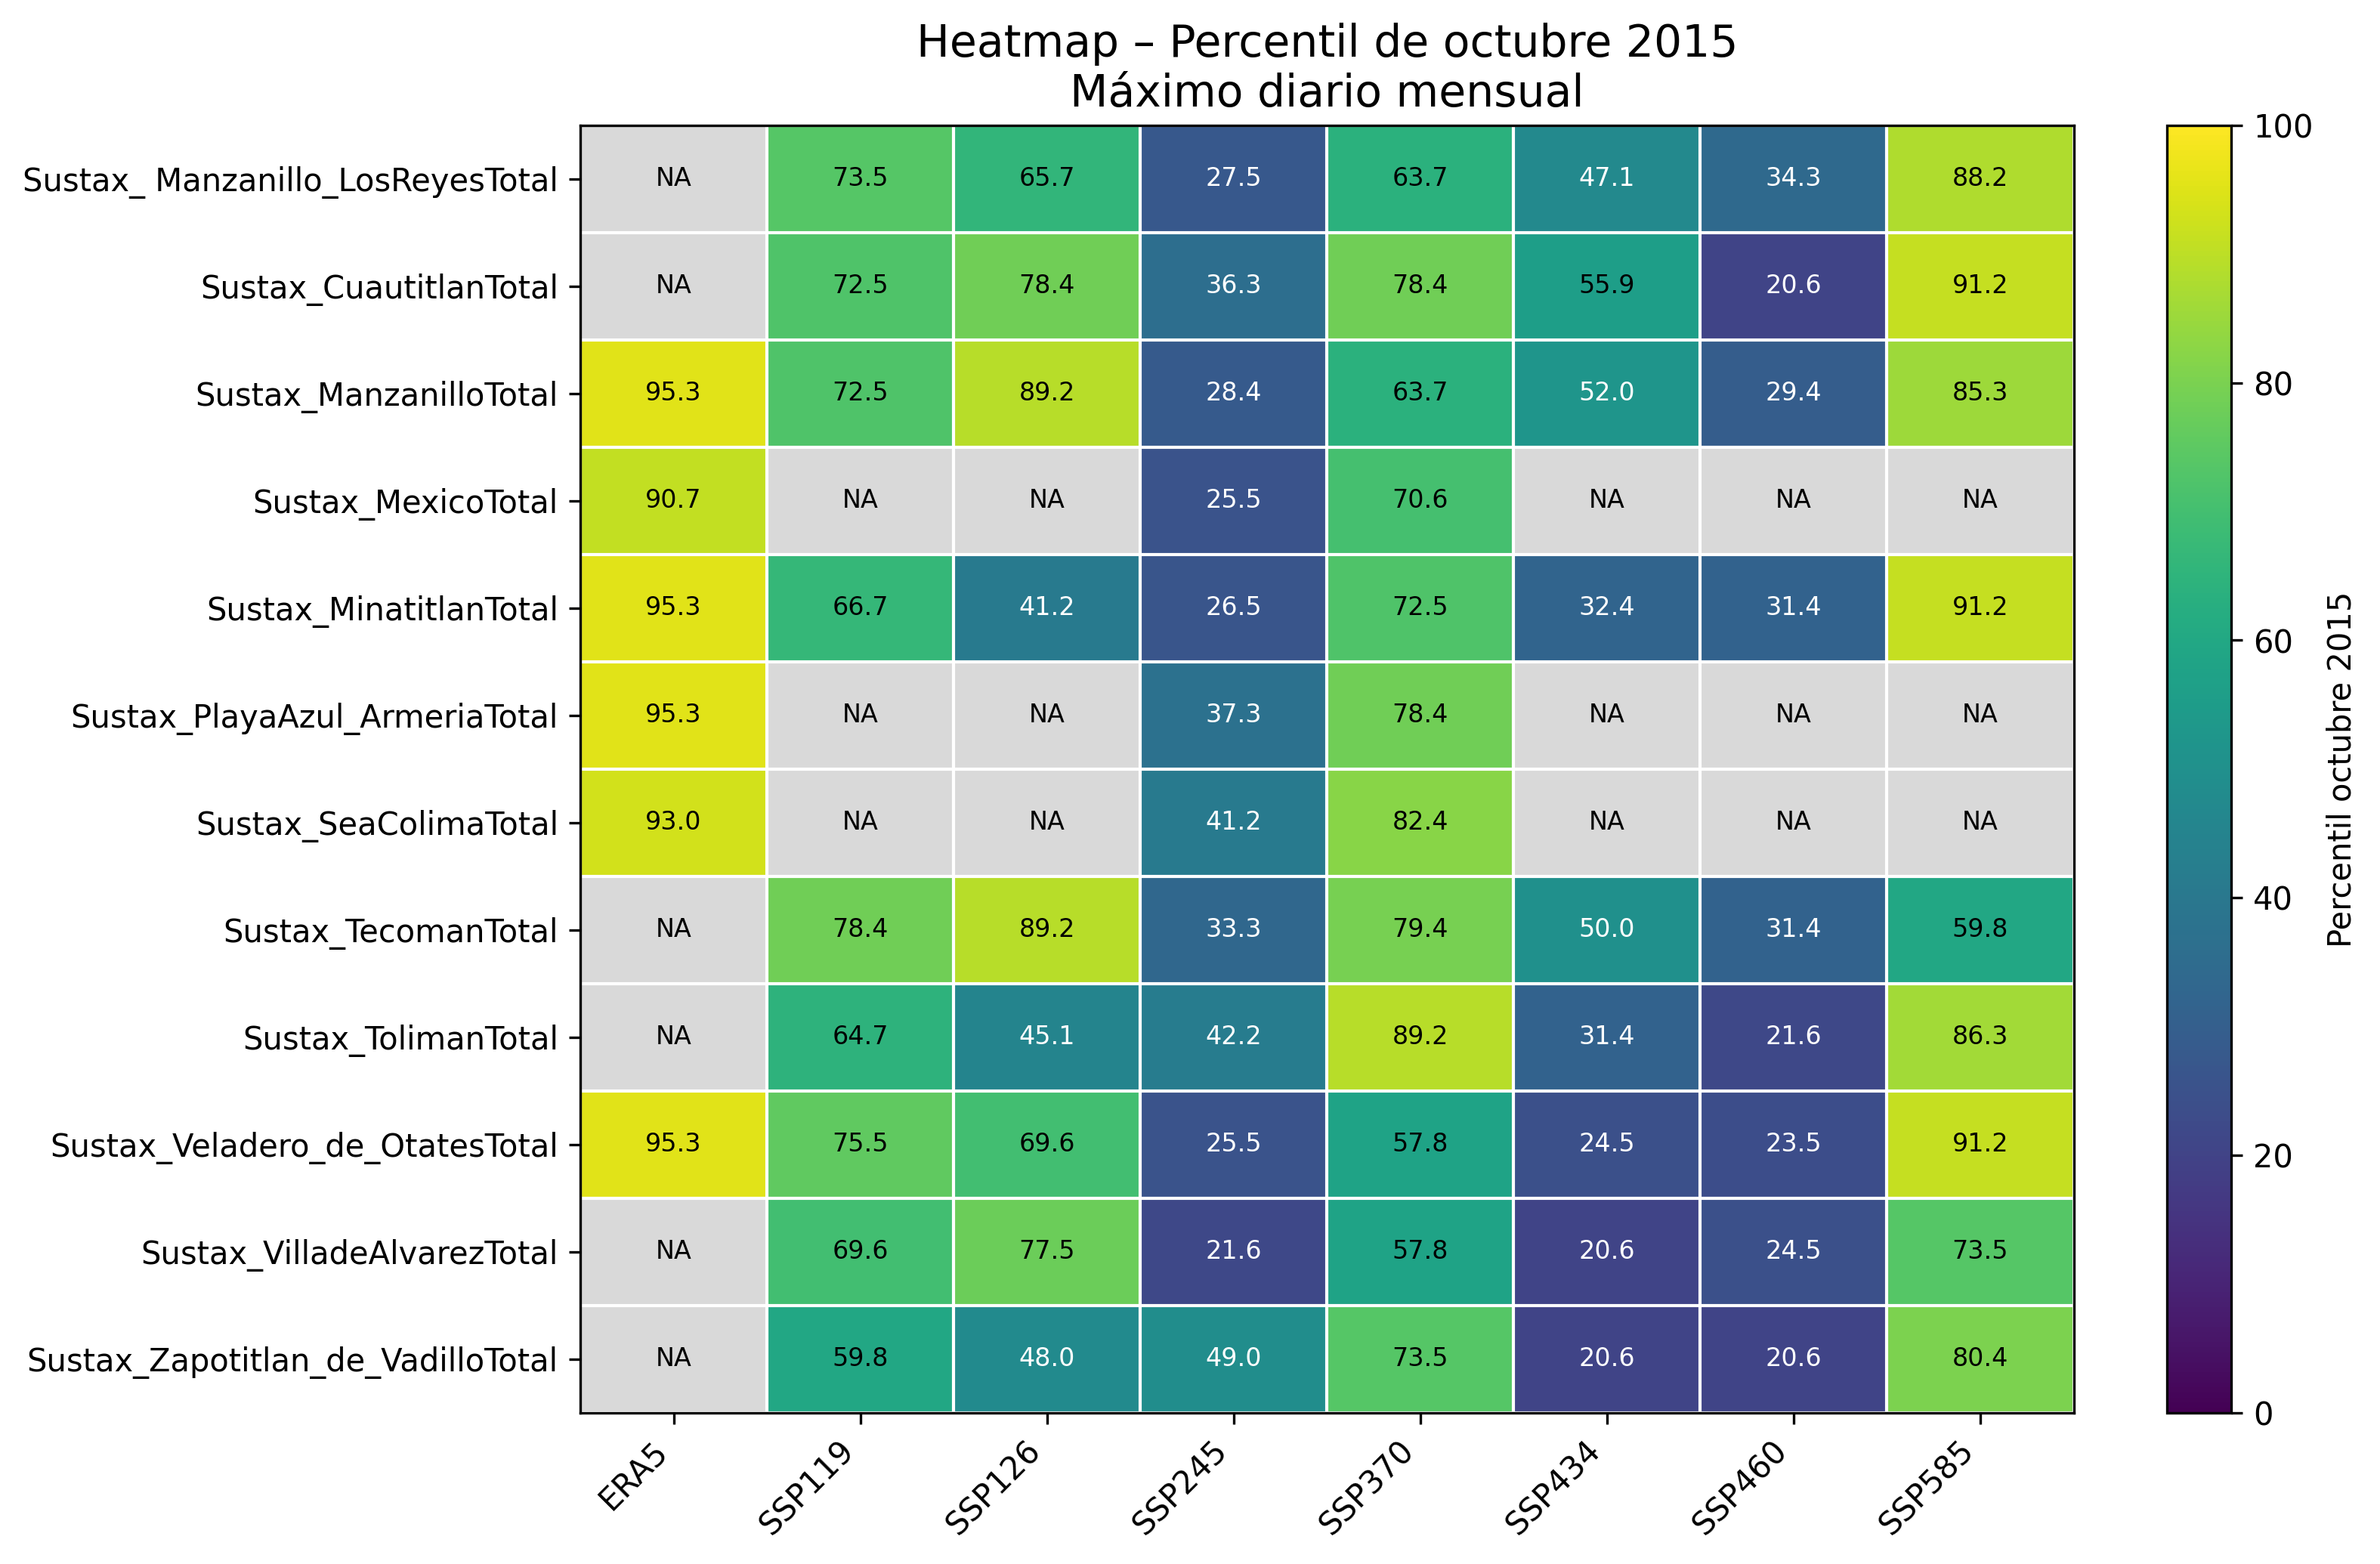


Figura: heatmap_october_percentile_weekly_FIXED.png
Existe: True


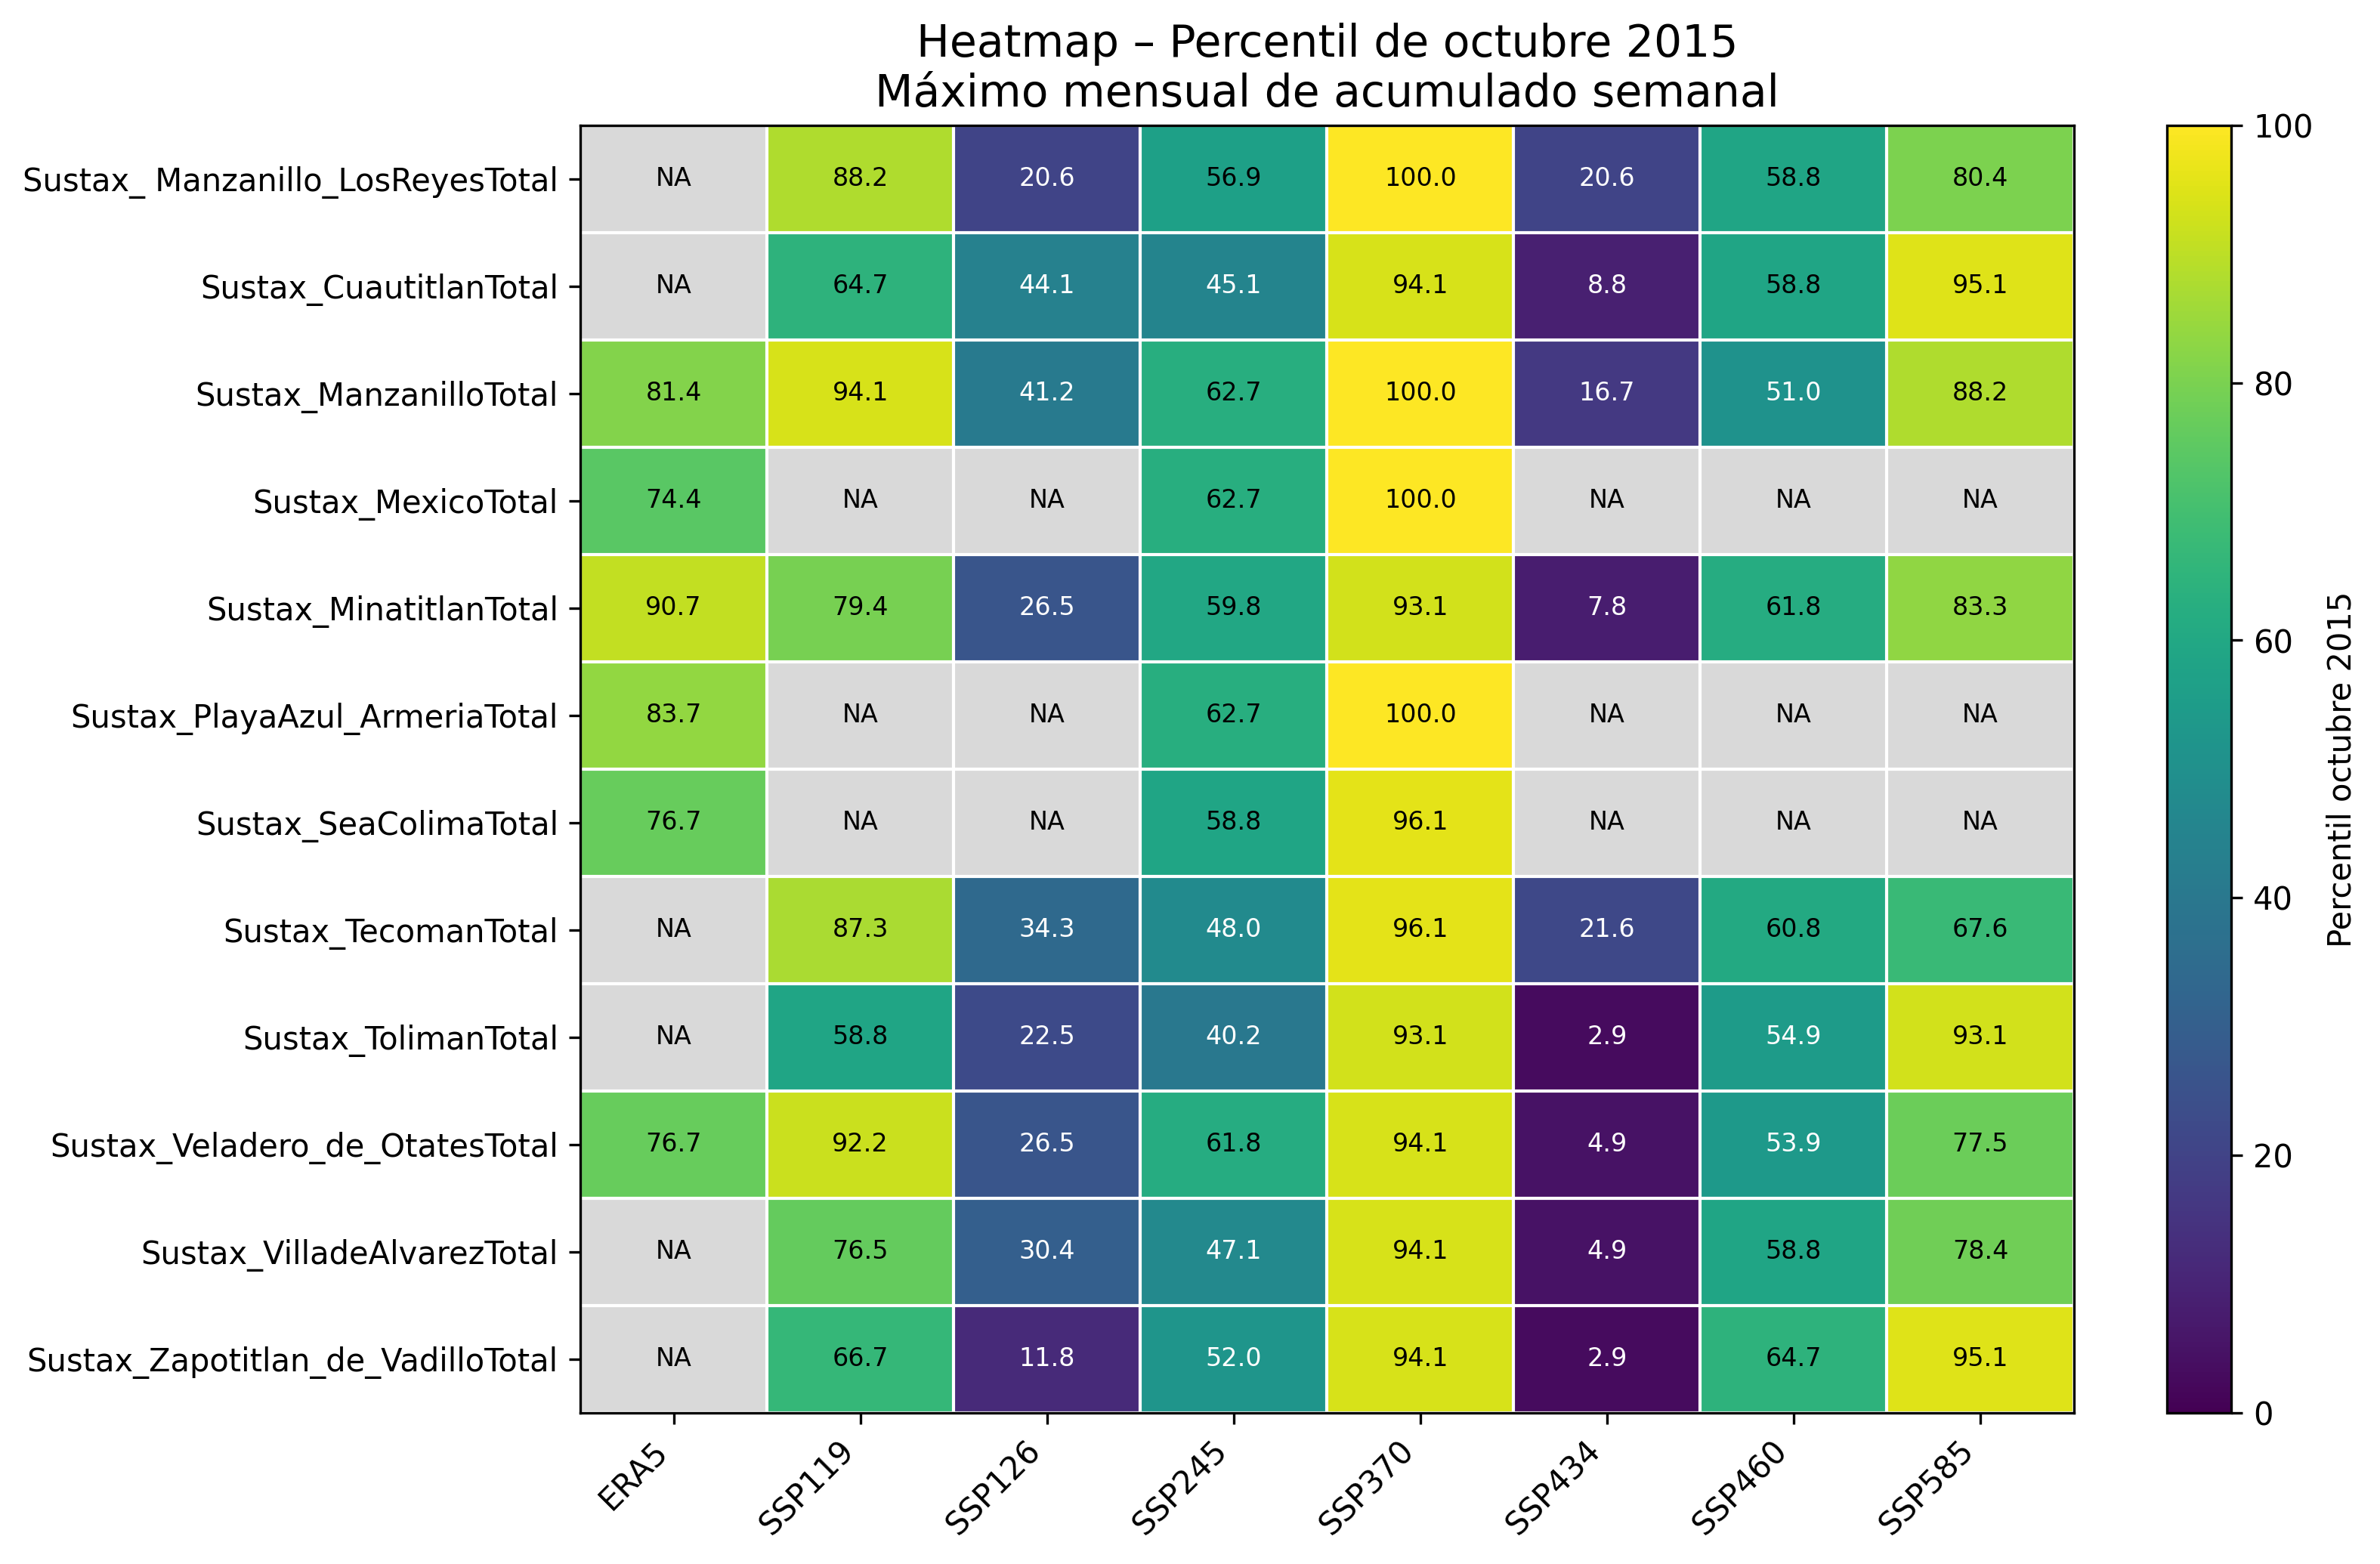


Figura: heatmap_ssp_october_percentile_daily.png
Existe: True


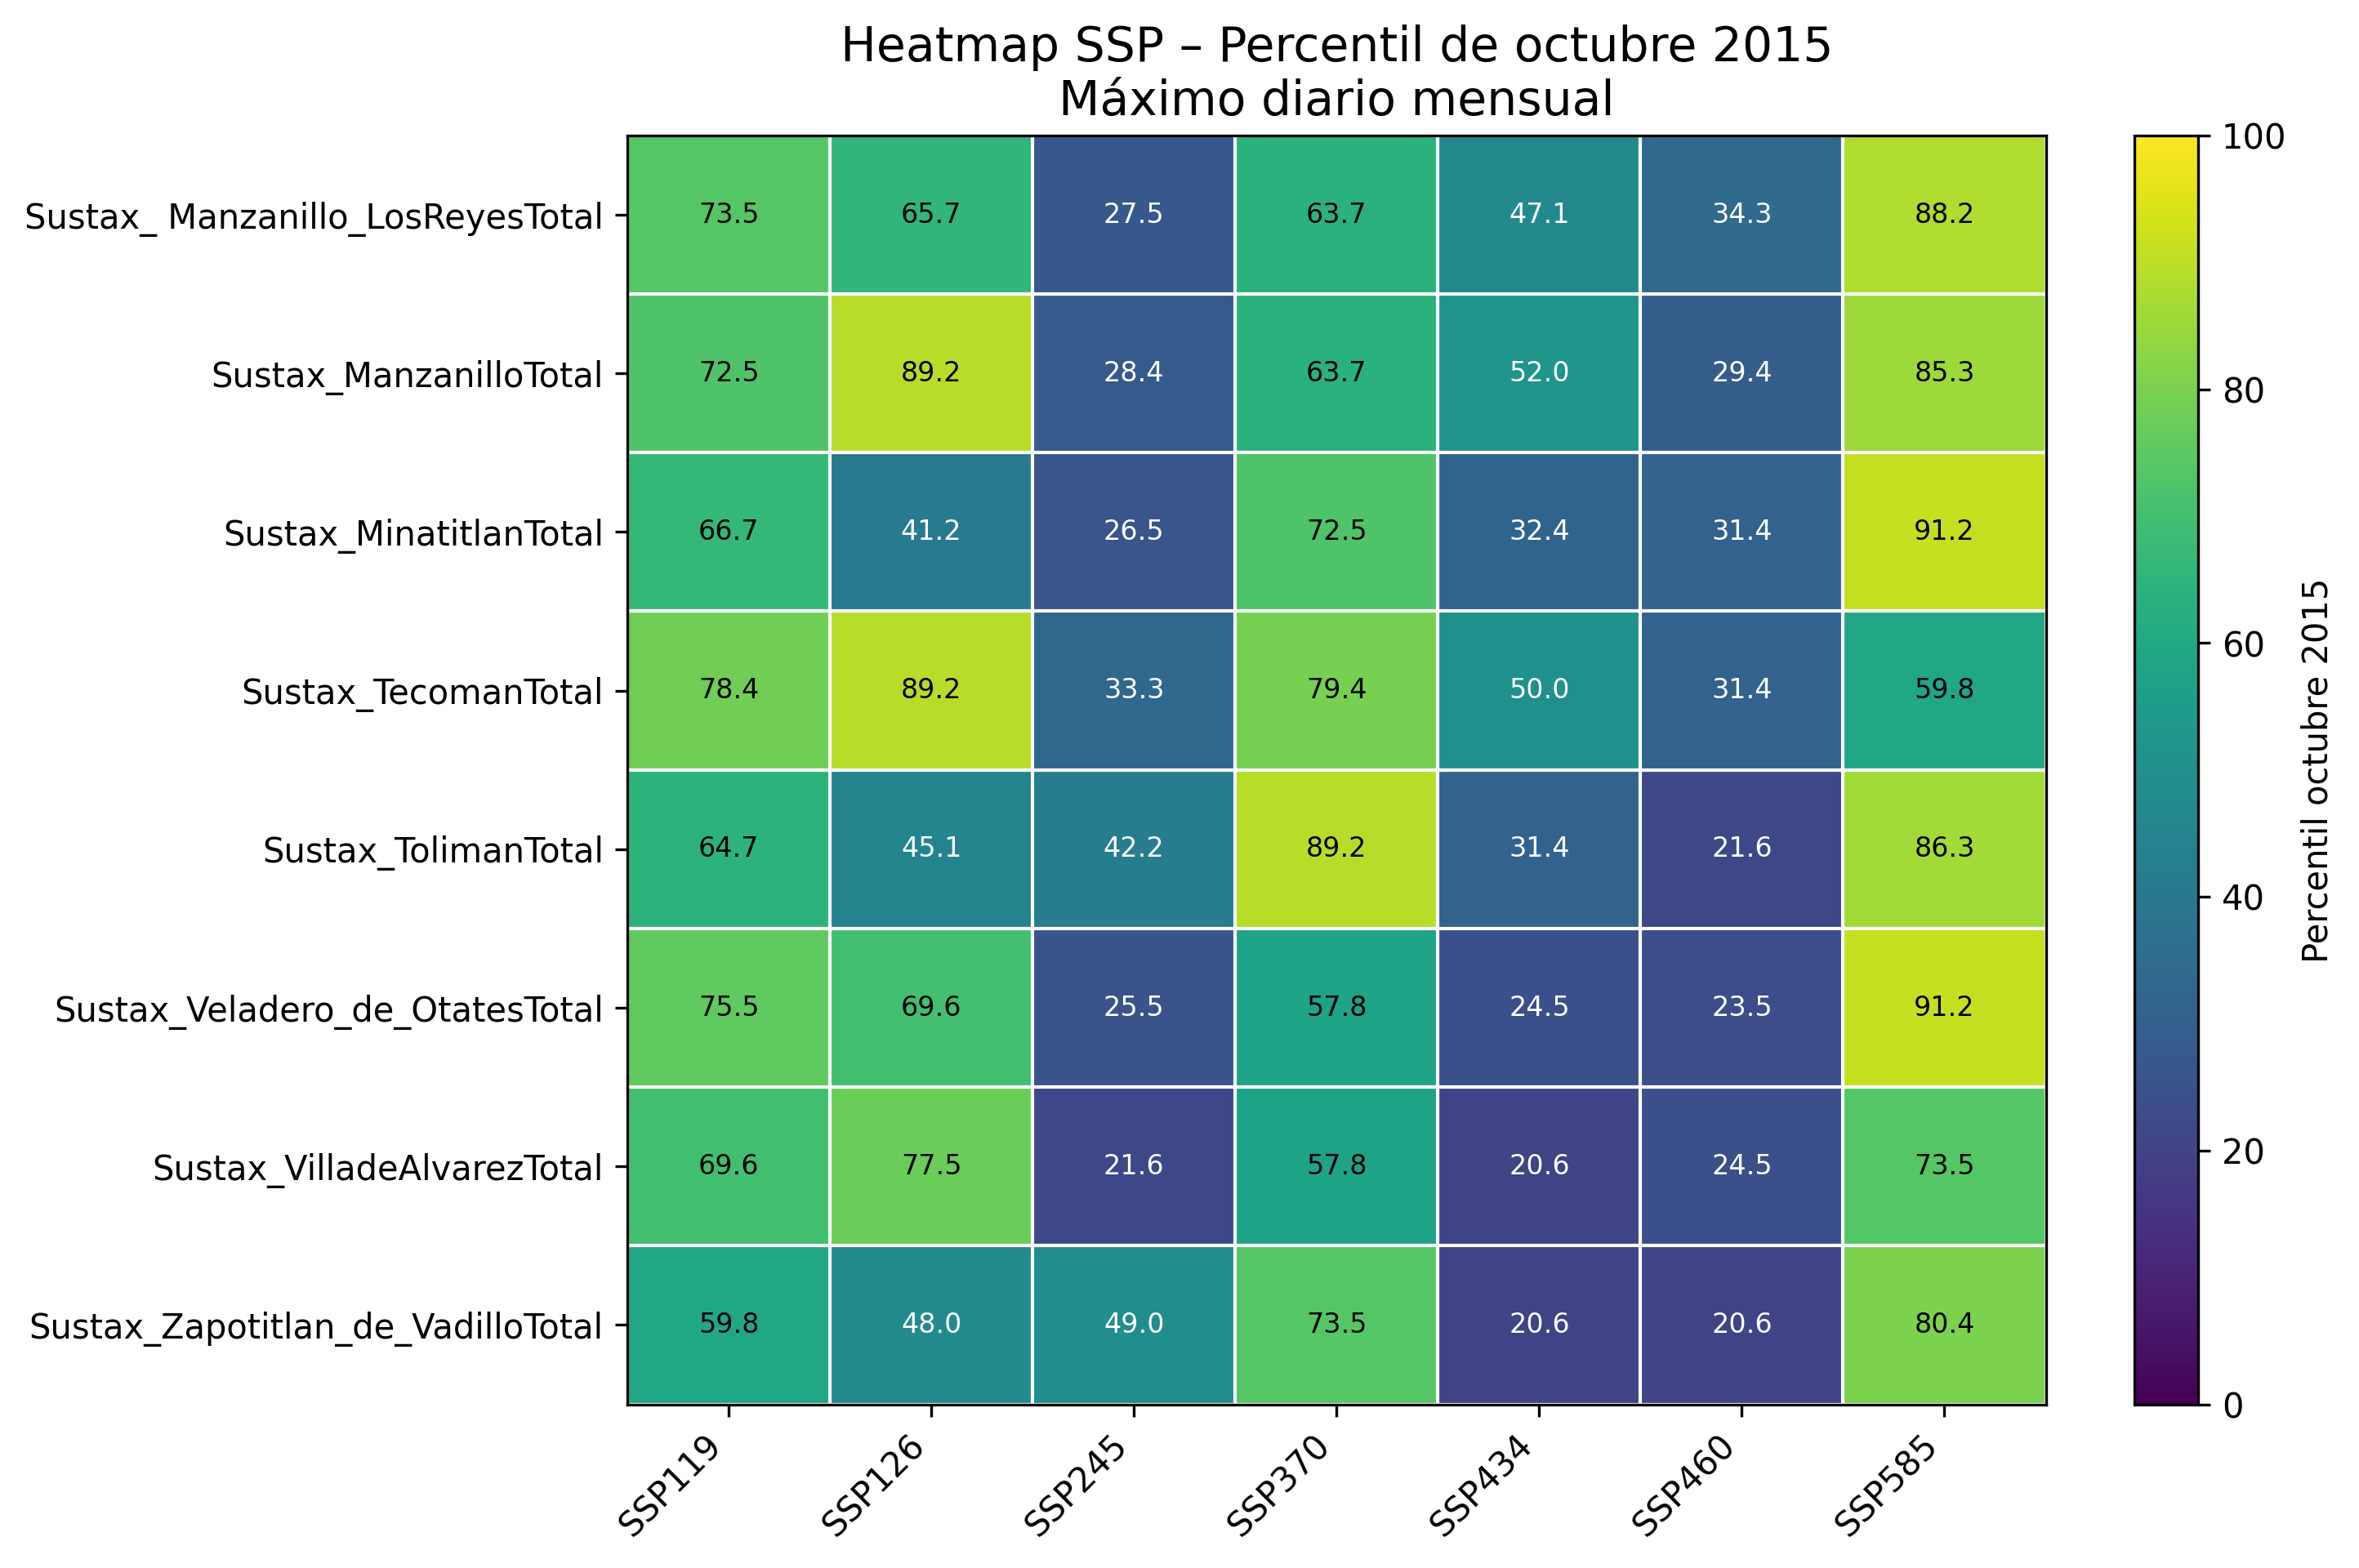


Figura: heatmap_ssp_october_percentile_weekly.png
Existe: True


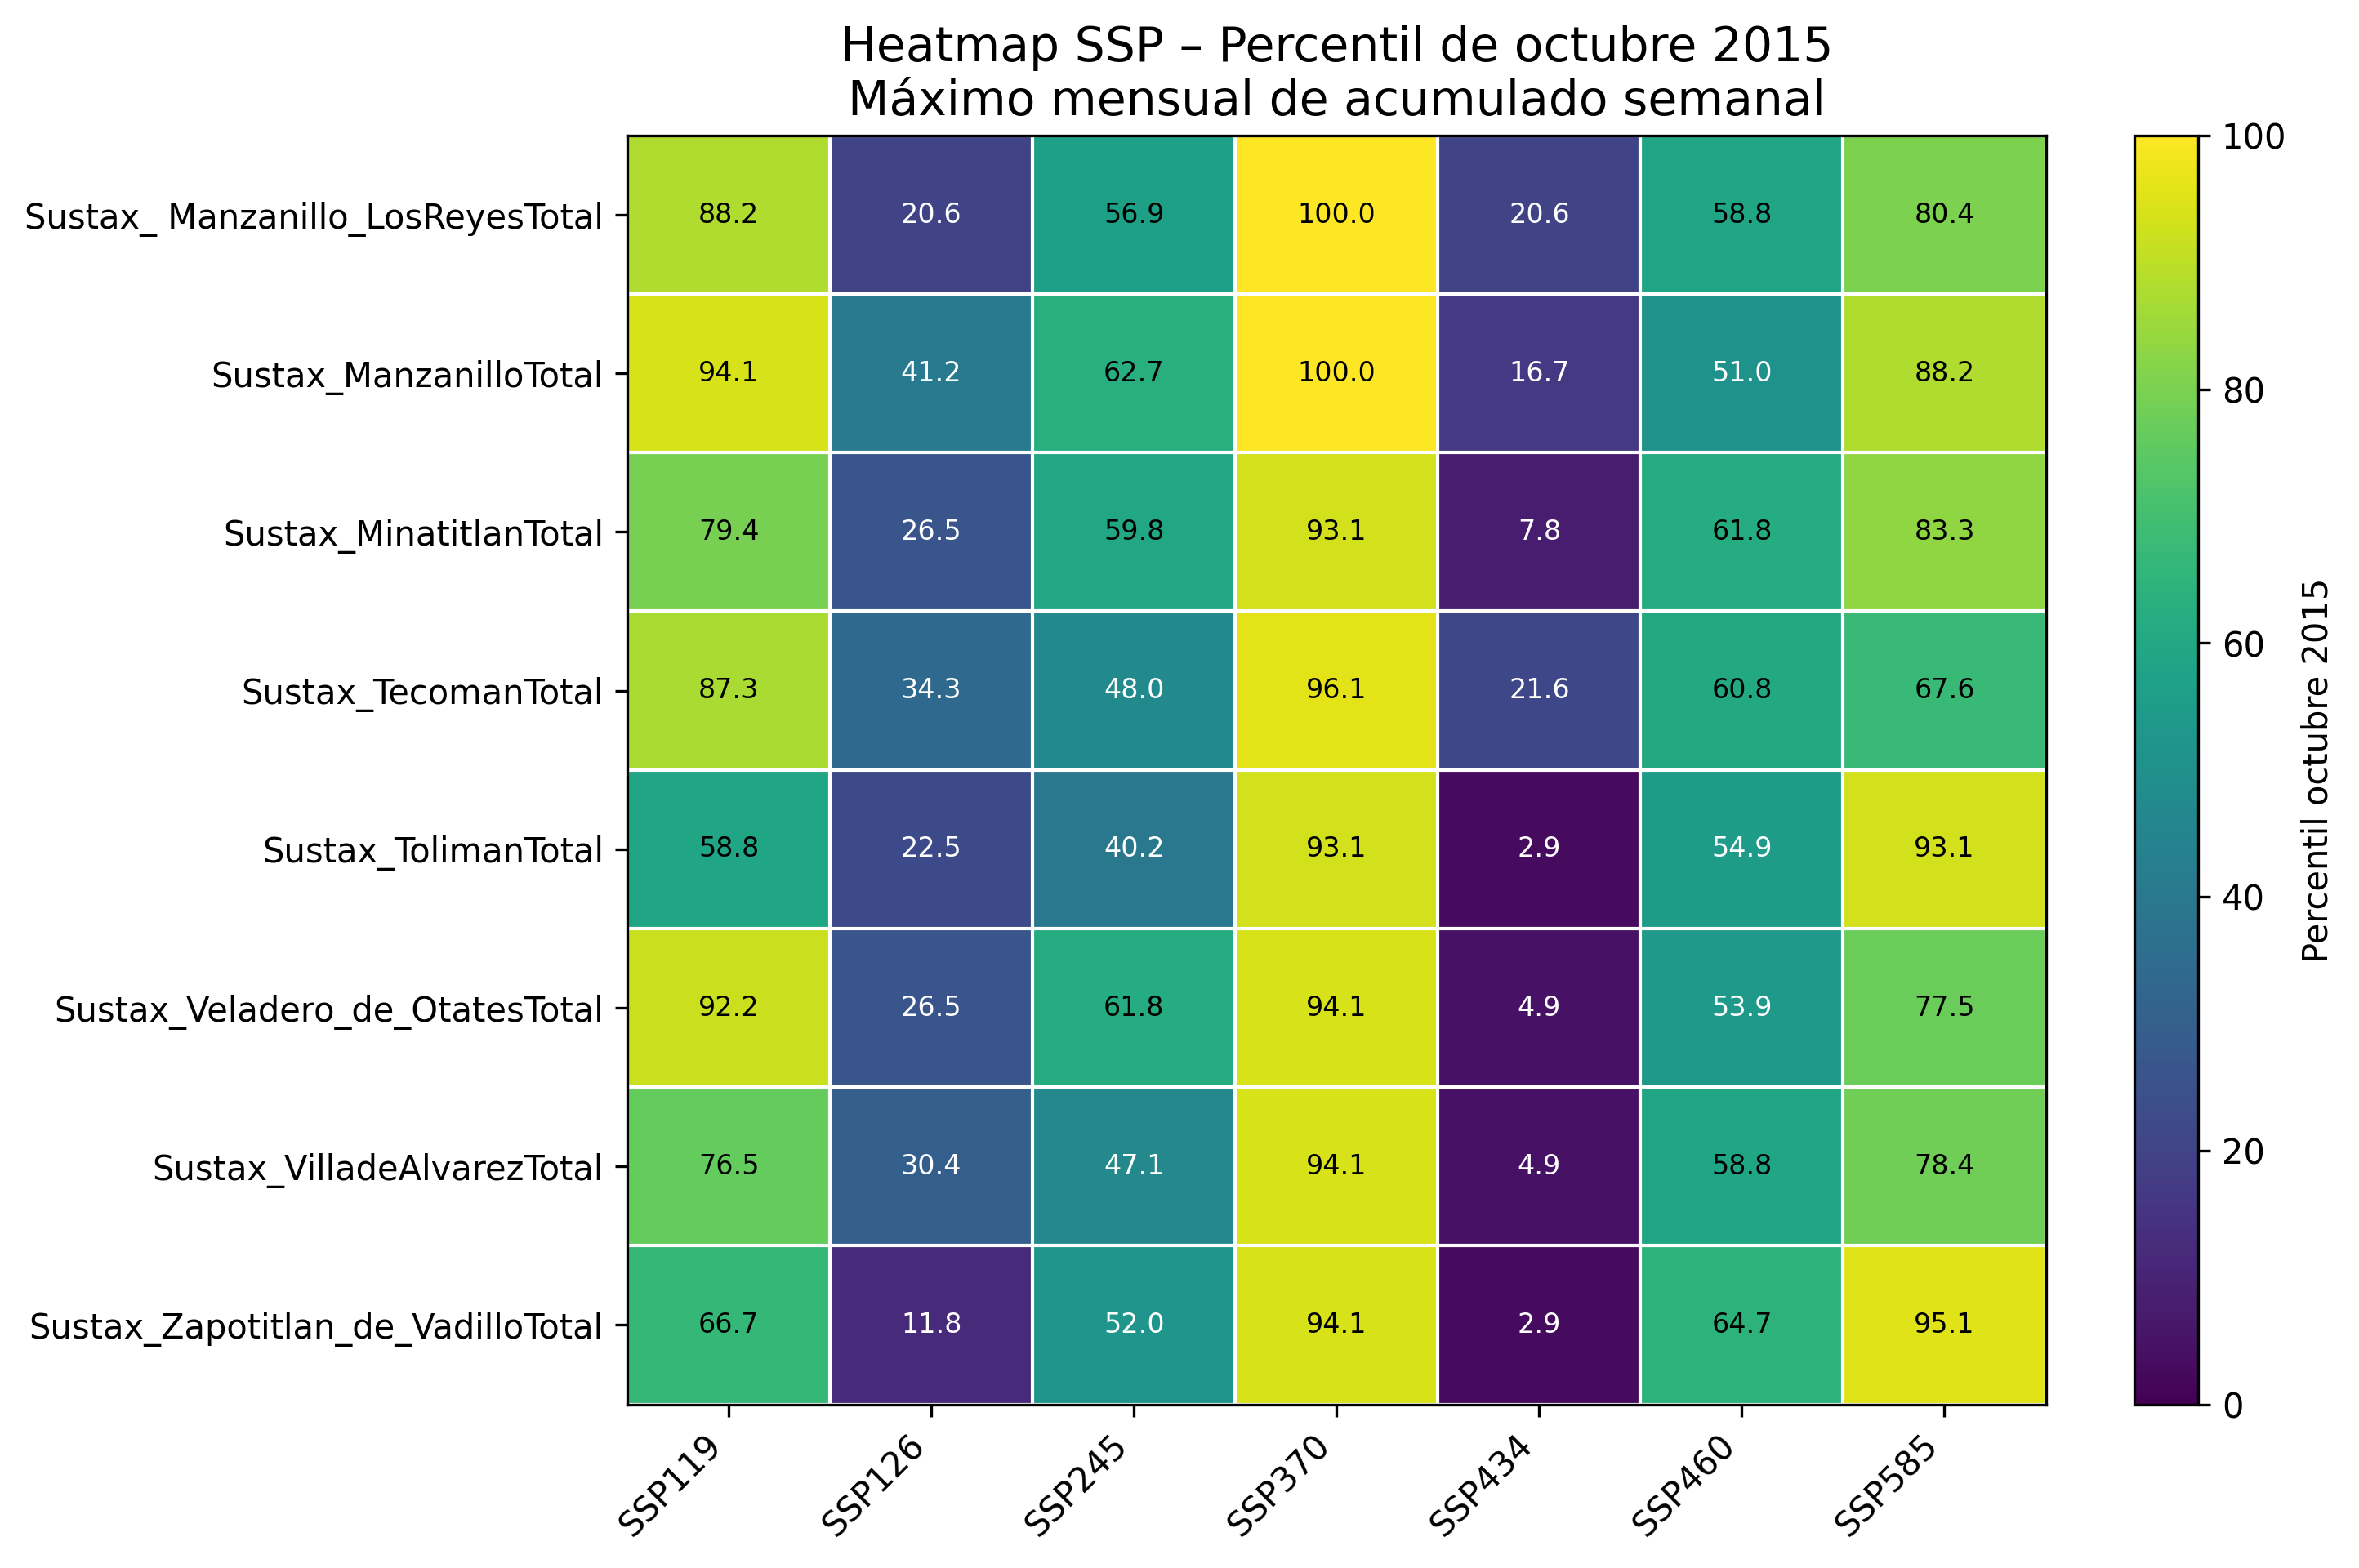

In [9]:
from IPython.display import Image, display

figuras_clave = [
    os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_daily_FIXED.png"),
    os.path.join(OUT_FIG_FOLDER, "heatmap_october_percentile_weekly_FIXED.png"),
    os.path.join(OUT_FIG_FOLDER_SSP, "heatmap_ssp_october_percentile_daily.png"),
    os.path.join(OUT_FIG_FOLDER_SSP, "heatmap_ssp_october_percentile_weekly.png"),
]

for fp in figuras_clave:
    print("\nFigura:", os.path.basename(fp))
    print("Existe:", os.path.exists(fp))
    if os.path.exists(fp):
        display(Image(filename=fp))